# The share that can never cost too much 🔀
### Berkshire's 1/1500 bound vs the Google twins — a law of one price you can watch work, in plain English

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Tradable for A-holders?: Busted](https://img.shields.io/badge/Tradable_for_A--holders%3F-Busted-8b949e?style=flat-square)

Berkshire Hathaway trades under two tickers. One share of **BRK.A** costs about as much as a house (~$750,000); one share of **BRK.B** costs about as much as a dinner for two (~$500). And there's a rule, written into the company's charter, that ties them together: **any A share can be converted, at any time, into exactly 1,500 B shares** — but *never* the other way.

That one-way door has a beautiful consequence, spelled out by Warren Buffett himself: the B **can never cost more than 1/1500th of the A** (if it did, anyone holding an A could mint 1,500 Bs and sell them for free money — and they do). But because the door only opens one way, the B **can trade at a discount**, and nobody can arbitrage it shut.

Google (Alphabet) also trades under two tickers — **GOOGL** (one vote) and **GOOG** (no vote) — but with **no conversion door at all**. Same company, same economics, no leash.

So: does the market really enforce Buffett's bound, every day, for thirty years? And is the B-discount the free lunch it looks like?

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the violation thresholds and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Daily split-adjusted closes (yfinance), BRK pair from the B's first trade (1996), Google pair from the 2014 class-C split, frozen as-of 2026-06-30. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from share_class_spreads import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX = data.load_real()
    PX = PX[PX.index <= "2026-06-30"]              # frozen as-of (docs/results.md)
    BRK = st.gap_series(PX, "BRK-A", "BRK-B", data.BRK_PARITY, start=data.BRKB_START)
    GOO = st.gap_series(PX, "GOOG", "GOOGL", 1.0, start=data.GOOG_START)
else:
    PX = BRK = GOO = None
print("real tape cached:", HAVE_REAL,
      "| BRK pair days:", (0 if BRK is None else len(BRK)),
      "| GOOG pair days:", (0 if GOO is None else len(GOO)))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'fingerprint': '145603f5d518', 'brk_days': 7583, 'brk_start': '1996-05-09', 'goog_days': 3078, 'goog_start': '2014-04-03', 'viol': [(0, 35.8, 2715), (10, 18.08, 1371), (50, 1.77, 134), (100, 0.24, 18)], 'worst_up_bps': 194, 'worst_up_date': '2020-03-13', 'worst_dn_bps': -700, 'worst_dn_date': '2009-02-20', 'asym_brk': 13.0, 'brk_dn50': 22.95, 'brk_up50': 1.77, 'asym_goog': 0.7, 'goog_up50': 40.16, 'goog_dn50': 26.74, 'mean_bps': -35.5, 'hac_t': -12.53, 'hac_lags': 10, 'median_bps': -8.2, 'std_bps': 82, 'p1_bps': -385.7, 'p99_bps': 62.7, 'brk_eras': [('1996-2009', -55.1, -10.82, 33.9), ('2010-2019', -7.1, -5.99, 44.9), ('2020-2026', -37.7, -10.83, 25.9)], 'goog_mean_bps': 51.6, 'goog_t': 6.45, 'goog_std': 149, 'goog_min': -435, 'goog_max': 531, 'goog_eras': [('2014-2017', 237.5, 28.59, 0), ('2018-2021', -4.8, -0.65, 50), ('2022-2026', -53.9, -14.74, 90)], 'rho_brk': 0.8566, 'hl_brk': 4.5, 'rho_goog': 0.9919, 'hl_goog': 85.2, 'pairs_diag': (8.42, 9.38, 33), 'pairs': [(2.0, 0.21, 0.38), (5.0, -0.95, -1.69), (10.0, -2.87, -4.75)], 'sw_diag': (4.27, 6.02, 158, 23), 'switch': [(0.5, -0.56, -1.03, -1.06, -0.93, -0.15, -0.39), (1.0, 0.14, 0.28, 0.13, 0.12, 0.14, 0.43), (2.0, 0.3, 0.73, 0.67, 0.74, -0.01, -0.04), (3.0, 0.42, 1.18, 0.76, 0.95, 0.14, 1.0)], 'syn': [('PLANTED bound -40 bps', -54.9, -33.86, 0.0, 52.64), ('NULL no bound, 0', -3.1, -1.5, 14.4, 16.98)]}


real tape cached: True | BRK pair days: 7583 | GOOG pair days: 3078


## The answer first

| Question | Answer |
|---|---|
| Does the market enforce the 1/1500 bound? | **Yes, visibly.** In 30 years the B closed more than half a percent *above* the bound on only **1.8% of days** (never more than ~2%, and that was the March-2020 panic) — while it spent **23% of days** more than half a percent *below*. Capped on top, free-falling underneath: exactly what a one-way door does. |
| What about the Google twins? | **No leash at all.** The voting share traded **+2.4% rich** in 2014–17, then **cheaper than the non-voting share 90% of days** since 2022. A spread with no conversion door just… wanders (it takes ~4 months to un-stretch, vs ~1 week for Berkshire's). |
| Is the B-discount free money for A-holders? | **No — and this is the fun part.** On paper, switching into the cheap B and back earns +4.3%/yr. But that profit assumes you trade *at the exact prices that made the discount look big* — mostly stale prints of the barely-traded A share. Wait one day for a real fill and the edge collapses to **~0.1%/yr, statistically nothing**, in every era. |

> The bound is **real**. The reason it's real is that *someone else* — A-holders with a conversion right — enforces it instantly. Which is precisely why there's nothing left for you.

## 1 · The claim

> *"BRK.B can never cost more than 1/1500th of BRK.A — a one-way conversion bound the market enforces daily. GOOG vs GOOGL has no bound at all."*

This isn't market folklore — it's in **Berkshire's own shareholder memo** ([compab.pdf](https://www.berkshirehathaway.com/compab.pdf)): each A converts into 1,500 B at the holder's option; B never converts back; so the B "can never sell for anything more than a tiny fraction above" parity, but "can sell at a discount." The Google twins are the perfect control group: two classes, same company, **no conversion right in either direction**.

## 2 · So what?

This is the cleanest natural experiment in finance: the **law of one price** with the arbitrage mechanism *visible in the charter*. If the bound holds where conversion exists and fails where it doesn't, you're watching arbitrage — not luck — hold prices together. And it sets up the tempting question every A-holder eventually asks: when my B twin goes on sale at a 2% discount, isn't switching classes free money?

## 3 · How would we even know?

Take every trading day since the B was born (1996-05-09, 7,583 days) and compute the **gap**: how far the B sits above or below exactly 1/1500th of the A (split-adjusted, so one number works for the whole history). Then:

1. **Count the violations.** Days the B closed *above* parity, by how much.
2. **Compare the two tails.** A one-way door should cap the top and leave the bottom free.
3. **Run the twin with no door.** Same math on GOOGL vs GOOG (3,078 days since 2014).
4. **Try to eat the discount.** Simulate an A-holder switching into the cheap B and back — with the one honesty rule that kills most paper edges: you trade at the *next* day's close, not at the price that generated the signal.

One caveat we name up front: an A share trades a few hundred times a day, so its 4 p.m. print is often minutes stale — tiny apparent "premiums" of a few hundredths of a percent are measurement noise, not broken arbitrage. We judge the bound where prints can't hide: half a percent and beyond.

## 4 · The teardown — let's actually look

**The gap itself, thirty years of it.** Watch the ceiling.

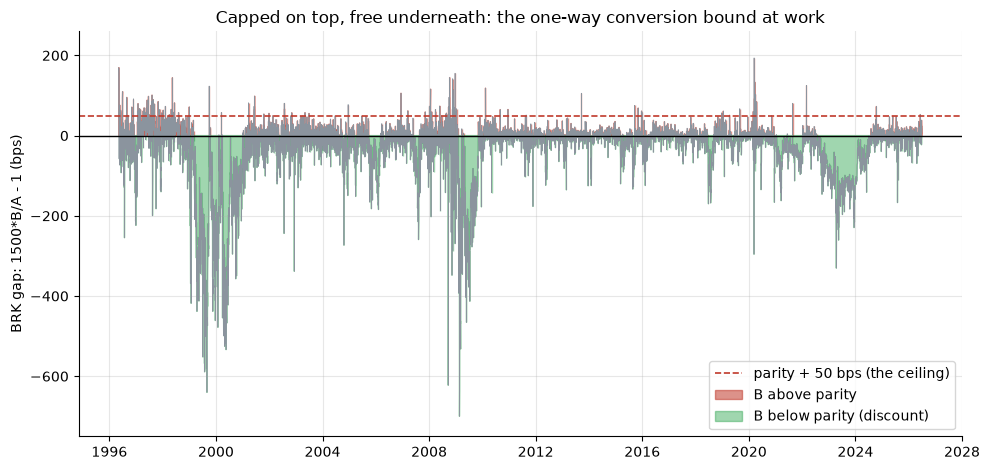

days B > parity+50bps: 1.77%   days B < parity-50bps: 22.95%


In [2]:
if HAVE_REAL:
    g = BRK*1e4
    fig, ax = plt.subplots(figsize=(10, 4.8))
    ax.plot(g.index, g.values, lw=.5, color=GREY)
    ax.axhline(0, color='k', lw=1)
    ax.axhline(50, color=RED, lw=1.2, ls='--', label='parity + 50 bps (the ceiling)')
    ax.fill_between(g.index, 0, g.where(g>0).values, color=RED, alpha=.55, label='B above parity')
    ax.fill_between(g.index, 0, g.where(g<0).values, color=GREEN, alpha=.45, label='B below parity (discount)')
    ax.set_ylabel('BRK gap: 1500*B/A - 1 (bps)'); ax.set_ylim(-750, 260)
    ax.set_title('Capped on top, free underneath: the one-way conversion bound at work')
    ax.legend(loc='lower right'); plt.tight_layout(); plt.show()
    print(f'days B > parity+50bps: {(BRK>0.005).mean()*100:.2f}%   days B < parity-50bps: {(BRK<-0.005).mean()*100:.2f}%')
else:
    print('cache missing - frozen numbers:', R['brk_up50'], '% above vs', R['brk_dn50'], '% below +/-50bps')

The picture *is* the verdict: above the line the gap is a thin red film (beyond +50 bps on just **1.8%** of days, worst **+194 bps** in the 2020 COVID panic), below it green stalactites reaching **-700 bps** in the 2009 crisis. The B spent **23%** of days more than 50 bps cheap — **13× more often** than it spent rich. That asymmetry is the one-way door, printed on the tape.

**Now the twin with no door.** Same company, two Google share classes, no conversion right — the spread has nothing to hold onto.

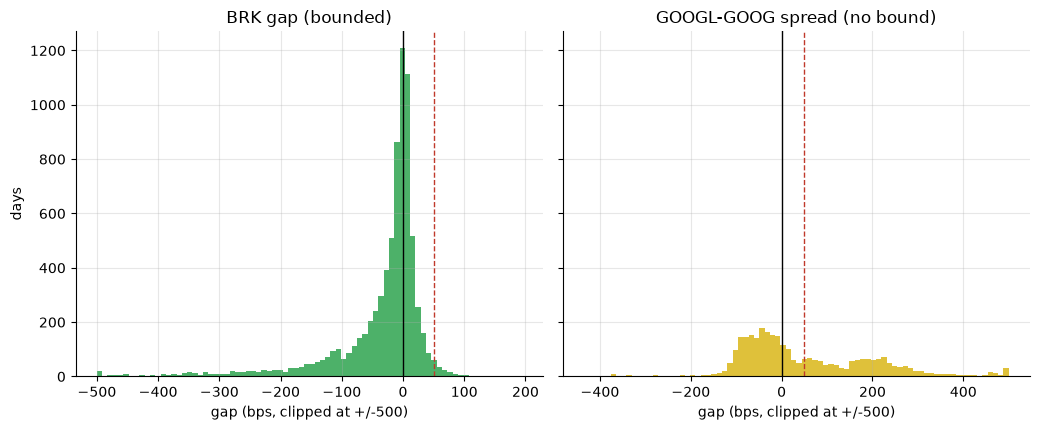

GOOGL premium: mean +52 bps, range -435 to +531 bps


In [3]:
if HAVE_REAL:
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4), sharey=True)
    for ax, s, lbl, col in [(axes[0], BRK*1e4, 'BRK gap (bounded)', GREEN),
                            (axes[1], GOO*1e4, 'GOOGL-GOOG spread (no bound)', AMBER)]:
        ax.hist(np.clip(s.values, -500, 500), bins=80, color=col, alpha=.85)
        ax.axvline(0, color='k', lw=1); ax.axvline(50, color=RED, ls='--', lw=1)
        ax.set_title(lbl); ax.set_xlabel('gap (bps, clipped at +/-500)')
    axes[0].set_ylabel('days')
    plt.tight_layout(); plt.show()
    print(f'GOOGL premium: mean {GOO.mean()*1e4:+.0f} bps, range {GOO.min()*1e4:+.0f} to {GOO.max()*1e4:+.0f} bps')
else:
    print('cache missing - GOOGL premium mean', R['goog_mean_bps'], 'bps, range', R['goog_min'], 'to', R['goog_max'])

Berkshire's histogram slams into a wall just past zero; Google's sprawls both ways (**-435 to +531 bps**). And the Google spread isn't even stable in *sign*: the voting share was **+238 bps rich** in 2014–17, then **-54 bps cheap** since 2022 — below the non-voting class on **90% of days** — because Alphabet's buybacks concentrate in the non-voting class. No door, no law. A stretched Berkshire gap heals in about **a week** (half-life 4.5 trading days); a stretched Google gap takes about **four months** (85 days).

**The free-lunch test.** The B trades at a real, persistent discount (average **-36 bps** — statistically rock-solid). So: switch into the B whenever it's ≥1% cheap, switch back at parity, pocket the difference? Here's that strategy under two rules — *paper* (you magically trade at the closing prints that defined the discount) and *honest* (you trade at the next day's close, like a human).

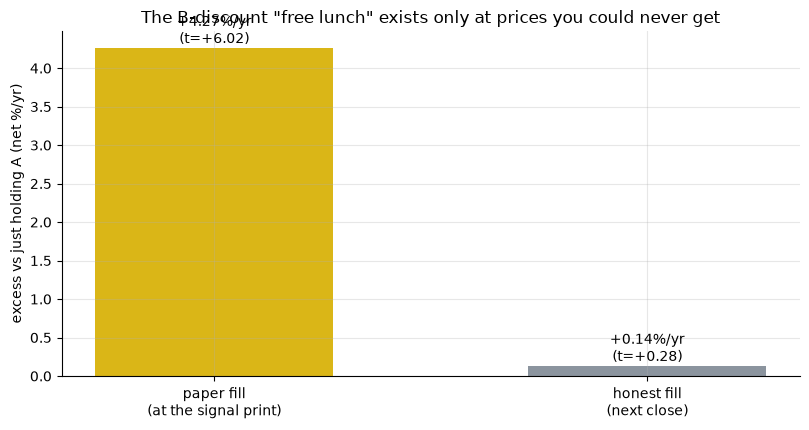

paper +4.27%/yr (t=+6.02)  ->  honest +0.14%/yr (t=+0.28)


In [4]:
labels = ['paper fill\n(at the signal print)', 'honest fill\n(next close)']
vals = [R['sw_diag'][0], R['switch'][1][1]]
ts = [R['sw_diag'][1], R['switch'][1][2]]
if HAVE_REAL:
    a = st.switch_overlay(PX, 'BRK-A', 'BRK-B', data.BRK_PARITY, thr=0.01, cost_bps=5.0, fill='same')
    b = st.switch_overlay(PX, 'BRK-A', 'BRK-B', data.BRK_PARITY, thr=0.01, cost_bps=5.0, fill='next')
    vals = [a['net_ann_pct'], b['net_ann_pct']]; ts = [a['hac_t'], b['hac_t']]
fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.bar(labels, vals, color=[AMBER, GREY], width=.55)
for i,(v,t) in enumerate(zip(vals, ts)):
    ax.annotate(f'{v:+.2f}%/yr\n(t={t:+.2f})', (i, v), ha='center', va='bottom')
ax.set_ylabel('excess vs just holding A (net %/yr)')
ax.set_title('The B-discount "free lunch" exists only at prices you could never get')
plt.tight_layout(); plt.show()
print(f'paper {vals[0]:+.2f}%/yr (t={ts[0]:+.2f})  ->  honest {vals[1]:+.2f}%/yr (t={ts[1]:+.2f})')

From **+4.3%/yr (t = 6.0)** to **+0.14%/yr (t = 0.28)** — the entire edge lived inside the prints that generated the signal. When the discount "appears," it's often the A share's stale, wide closing print; by the first close at which you could actually trade, the gap has already snapped most of the way back (that one-week half-life cuts both ways). The quants notebook shows the same collapse at every threshold — 0.5%, 1%, 2%, 3% — in every era, and for the hedge-fund version of the trade too.

## 5 · The verdict

- **Signal — Real.** The one-way bound is on the tape: beyond +50 bps on only **1.8%** of days (max +194 bps, in a panic) vs **23%** of days below — a 13× asymmetry — plus a persistent average discount of **-36 bps** that is statistically unambiguous. The unleashed Google twins confirm the mechanism by lacking it.
- **Tradability — Mirage.** Every scheme to harvest the gap dies under an honest fill (+0.2%/yr at best, statistically zero), before you even mention the $750k minimum A share.
- **"Free money for A-holders"? — Busted.** The +4.3%/yr paper edge is a trade-at-the-signal-print illusion; delayed one close it reads t ≤ 1.2 everywhere.

## 6 · Going further 🚪

- **Why does the discount exist at all?** Because the door only opens one way, closing it from below needs someone to *sell A and buy B* in size — and A's illiquidity makes that slow. The bound is enforced in seconds; the discount heals in a week.
- **The Google lesson.** "Voting premium" sounds like a constant of nature; it flipped sign when buybacks tilted to the non-voting class. Spreads without a mechanism are narratives, not laws.
- **Build your own.** The engine takes any two-class pair — try Heico A/HEI, Alphabet against other bridgeless twins, or a CEF against its NAV ([367-closed-end-fund-discount](../../367-closed-end-fund-discount/README.md)).

*Think you can catch the discount faster than the conversion arbitrageurs? Show the switch overlay clearing t = 2 with a next-close fill — then we'll talk.*